In [ ]:

from google.colab import drive
drive.mount('/content/drive')

TRAIN_IMG_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/image_RGB"
TRAIN_MASK_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/label"
VAL_IMG_DIR   = "/content/drive/MyDrive/Dataset/GIDsplit/val/image_RGB"
VAL_MASK_DIR  = "/content/drive/MyDrive/Dataset/GIDsplit/val/label"
SAVE_DIR      = "/content/drive/MyDrive/checkpoints_unet_attn"


Mounted at /content/drive


In [ ]:

import os, time, random, gc, numpy as np
from pathlib import Path
from PIL import Image

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)


In [ ]:

CLASS_COLORS = [
    (0, 0, 0),      # 0 background
    (255, 0, 0),    # 1 build-up
    (255, 255, 0),  # 2 farmland
    (0, 255, 0),    # 3 forest
    (0, 255, 255),  # 4 meadow
    (0, 0, 255),    # 5 water
]
CLASS_NAMES  = ["background","build-up","farmland","forest","meadow","water"]
NUM_CLASSES  = len(CLASS_COLORS)

IMG_EXTS  = {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
MASK_EXTS = [".png",".tif",".tiff",".jpg",".jpeg",".bmp"]


In [ ]:

def list_images(folder: Path):
    folder = Path(folder)
    return [p for p in sorted(folder.iterdir()) if p.suffix.lower() in IMG_EXTS]

def rgb_to_class_np(mask_rgb: np.ndarray) -> np.ndarray:
    out = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for idx, (r,g,b) in enumerate(CLASS_COLORS):
        m = (mask_rgb[...,0]==r) & (mask_rgb[...,1]==g) & (mask_rgb[...,2]==b)
        out[m] = idx
    return out

def colorize_idx(mask_idx: np.ndarray) -> np.ndarray:
    lut = np.array(CLASS_COLORS, dtype=np.uint8)
    if isinstance(mask_idx, torch.Tensor):
        mask_idx = mask_idx.cpu().numpy()
    return lut[mask_idx.astype(np.int64)]


In [ ]:

class GIDPatchDataset(Dataset):
    def __init__(self, image_dir, mask_dir, patch_size=256, samples_per_image=4,
                 mode="train", augment=True, mask_suffix="_label"):
        self.image_dir = Path(image_dir)
        self.mask_dir  = Path(mask_dir)
        self.patch_size = patch_size
        self.samples_per_image = samples_per_image
        self.mode = mode
        self.augment = augment and (mode=="train")
        self.mask_suffix = mask_suffix

        self.img_paths = list_images(self.image_dir)
        assert len(self.img_paths) > 0, f"No images in {self.image_dir}"

        self.mask_paths = [self._find_mask_path(p) for p in self.img_paths]


        self._sizes = []
        for p in self.img_paths:
            with Image.open(p) as im:
                self._sizes.append(im.size) 

        self.virtual_len = max(1, len(self.img_paths) * (samples_per_image if mode=="train" else 1))

    def _find_mask_path(self, img_path: Path) -> Path:
        stem = img_path.stem
        for ext in MASK_EXTS + [img_path.suffix.lower()]:
            p = self.mask_dir / f"{stem}{self.mask_suffix}{ext}"
            if p.exists():
                return p
        for p in self.mask_dir.glob(f"{stem}*label*"):
            if p.suffix.lower() in MASK_EXTS:
                return p
        raise FileNotFoundError(f"No mask for {img_path.name}")

    def __len__(self): return self.virtual_len

    def _sample_coords(self, W, H):
        ps = self.patch_size
        if self.mode == "train":
            x = 0 if W<=ps else np.random.randint(0, W-ps+1)
            y = 0 if H<=ps else np.random.randint(0, H-ps+1)
        else:
            x = max(0, (W-ps)//2); y = max(0, (H-ps)//2)
        return x, y

    def __getitem__(self, idx):
        idx_img = idx % len(self.img_paths) if self.mode=="train" else idx
        ip, mp = self.img_paths[idx_img], self.mask_paths[idx_img]

        with Image.open(ip) as im:
            W, H = im.size
        x, y = self._sample_coords(W, H)
        ps = self.patch_size

        with Image.open(ip) as im:
            crop = im.convert("RGB").crop((x, y, x+ps, y+ps))
            img = torch.from_numpy(np.array(crop, np.uint8)).permute(2,0,1).float()/255.0

        with Image.open(mp) as ma:
            cropm = ma.convert("RGB").crop((x, y, x+ps, y+ps))
            mask = torch.from_numpy(rgb_to_class_np(np.array(cropm, np.uint8))).long()

        if self.augment:
            if np.random.rand()<0.5: img = torch.flip(img,[2]); mask = torch.flip(mask,[1])
            if np.random.rand()<0.5: img = torch.flip(img,[1]); mask = torch.flip(mask,[0])
            k = np.random.randint(0,4)
            if k: img=torch.rot90(img,k,[1,2]); mask=torch.rot90(mask,k,[0,1])

        return img, mask


In [ ]:

class DoubleConv(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1,bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
    def forward(self,x): return self.seq(x)

def center_crop(t: torch.Tensor, target_hw):
    """Crop (or pad if needed) t to target (H,W)."""
    H, W = target_hw
    if t.shape[-2:] == (H, W): return t
    return TF.center_crop(t, [H, W])


class AttentionGate(nn.Module):
    """
    F_g: channels of gating (decoder) signal
    F_l: channels of skip (encoder) signal
    F_int: intermediate channels (usually F_l // 2)
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
     
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi  


In [ ]:

class UNetWithAttention(nn.Module):
    def __init__(self, in_ch=3, num_classes=6, base_ch=64):
        super().__init__()
        c = base_ch
        
        self.inc = DoubleConv(in_ch, c)
        self.d1  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(c,   c*2))
        self.d2  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(c*2, c*4))
        self.d3  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(c*4, c*8))
        self.d4  = nn.Sequential(nn.MaxPool2d(2), DoubleConv(c*8, c*16))
 
        self.u1, self.c1 = nn.ConvTranspose2d(c*16, c*8, 2, 2),  DoubleConv(c*16, c*8)
        self.u2, self.c2 = nn.ConvTranspose2d(c*8,  c*4, 2, 2),  DoubleConv(c*8,  c*4)
        self.u3, self.c3 = nn.ConvTranspose2d(c*4,  c*2, 2, 2),  DoubleConv(c*4,  c*2)
        self.u4, self.c4 = nn.ConvTranspose2d(c*2,  c,   2, 2),  DoubleConv(c*2,  c)
        self.outc = nn.Conv2d(c, num_classes, 1)

       
        self.ag1 = AttentionGate(F_g=c*8, F_l=c*8, F_int=c*4) 
        self.ag2 = AttentionGate(F_g=c*4, F_l=c*4, F_int=c*2)
        self.ag3 = AttentionGate(F_g=c*2, F_l=c*2, F_int=c)  
        self.ag4 = AttentionGate(F_g=c,   F_l=c,   F_int=c//2) 

    def forward(self, x):

        x1 = self.inc(x)
        x2 = self.d1(x1)
        x3 = self.d2(x2)
        x4 = self.d3(x3)
        x5 = self.d4(x4)

     
        d4 = self.u1(x5)
        x4c = center_crop(x4, d4.shape[-2:])
       
        x4g = self.ag1(d4, x4c)
        d4  = self.c1(torch.cat([d4, x4g], dim=1))

        d3 = self.u2(d4)
        x3c = center_crop(x3, d3.shape[-2:])
        x3g = self.ag2(d3, x3c)
        d3  = self.c2(torch.cat([d3, x3g], dim=1))

        d2 = self.u3(d3)
        x2c = center_crop(x2, d2.shape[-2:])
        x2g = self.ag3(d2, x2c)
        d2  = self.c3(torch.cat([d2, x2g], dim=1))

        d1 = self.u4(d2)
        x1c = center_crop(x1, d1.shape[-2:])
        x1g = self.ag4(d1, x1c)
        d1  = self.c4(torch.cat([d1, x1g], dim=1))

        return self.outc(d1)


In [ ]:

def compute_confusion_matrix(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    k = (target >= 0) & (target < num_classes)
    inds = num_classes * target[k].to(torch.int64) + pred[k]
    return torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes)

def metrics_from_cm(cm: torch.Tensor):
    cm = cm.to(torch.float32)
    tp = cm.diag()
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    iou = tp / (tp + fp + fn).clamp_min(1e-6)
    miou = float(iou.mean().item())
    support = cm.sum(1)
    pa = tp / support.clamp_min(1e-6)
    valid = support > 0
    mpa = float(pa[valid].mean().item()) if valid.any() else float("nan")
    oa = float((tp.sum() / cm.sum().clamp_min(1e-6)).item())
    return iou.tolist(), miou, pa.tolist(), mpa, oa


In [ ]:

@torch.no_grad()
def validate(model, loader, device, amp=True):
    model.eval()
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)
    tot_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                             enabled=amp, dtype=torch.float16):
            logits = model(xb)
            loss = criterion(logits, yb)
        tot_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(1)
        cm_total += compute_confusion_matrix(preds.cpu(), yb.cpu(), NUM_CLASSES)
    iou, miou, pa, mpa, oa = metrics_from_cm(cm_total)
    return tot_loss/len(loader.dataset), cm_total, iou, miou, pa, mpa, oa

def train(train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=1e-4,
          base_ch=64, mixed_precision=True, save_dir=SAVE_DIR):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    torch.backends.cudnn.benchmark = True

   
    model = UNetWithAttention(3, NUM_CLASSES, base_ch=base_ch).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))

    os.makedirs(save_dir, exist_ok=True)
    best_miou = -1.0
    last_cm = None

    for ep in range(epochs):
        model.train()
        run_loss, t0 = 0.0, time.time()
        for step, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                                 enabled=mixed_precision, dtype=torch.float16):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            run_loss += float(loss.item())

            if (step+1) % 50 == 0:
                print(f"Epoch {ep+1}/{epochs} | step {step+1}/{len(train_loader)} | "
                      f"loss {run_loss/(step+1):.4f}")

        sch.step()
        v_loss, cm, iou, miou, pa, mpa, oa = validate(model, val_loader, device, amp=mixed_precision)
        last_cm = cm.clone()
        print(f"Epoch {ep+1}: train_loss={run_loss/len(train_loader):.4f}, "
              f"val_loss={v_loss:.4f}, mIoU={miou:.4f}, mPA={mpa:.4f}, OA={oa:.4f}")
        for i,(ii,pp) in enumerate(zip(iou, pa)):
            print(f"  class {i} ({CLASS_NAMES[i]}): IoU={ii:.4f} | PA={pp:.4f}")

        
        is_best = miou > best_miou
        best_miou = max(best_miou, miou)
        torch.save(model.state_dict(), os.path.join(save_dir, f"epoch_{ep+1:03d}.pth"))
        if is_best:
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model_state_dict.pth"))
            print(f"* New best mIoU {miou:.4f} — saved best.")
        if device.type=="cuda":
            torch.cuda.empty_cache(); gc.collect()

    return model, last_cm


In [ ]:

BATCH_SIZE = 8
PATCH_SIZE = 256
SAMPLES_PER_IMG = 4
NUM_WORKERS = 2

train_ds = GIDPatchDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=SAMPLES_PER_IMG,
                           mode="train", augment=True, mask_suffix="_label")
val_ds   = GIDPatchDataset(VAL_IMG_DIR, VAL_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=1,
                           mode="val", augment=False, mask_suffix="_label")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=max(1,BATCH_SIZE//2), shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train images:", len(train_ds.img_paths))
print("Val images:", len(val_ds.img_paths))
xb, yb = next(iter(train_loader))
print("Sanity batch:", xb.shape, yb.shape)


Train images: 120
Val images: 30
Sanity batch: torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256])


In [ ]:

model, cm = train(train_loader, val_loader,
                  epochs=20, lr=1e-3, weight_decay=1e-4,
                  base_ch=64, mixed_precision=True,
                  save_dir=SAVE_DIR)


Device: cuda


/tmp/ipython-input-1171589768.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))


Epoch 1/20 | step 50/60 | loss 1.4279
Epoch 1: train_loss=1.3918, val_loss=1.2809, mIoU=0.2347, mPA=0.3844, OA=0.4703
  class 0 (background): IoU=0.2918 | PA=0.4413
  class 1 (build-up): IoU=0.3413 | PA=0.7702
  class 2 (farmland): IoU=0.0000 | PA=0.0000
  class 3 (forest): IoU=0.3091 | PA=0.5574
  class 4 (meadow): IoU=0.0000 | PA=0.0000
  class 5 (water): IoU=0.4658 | PA=0.5377
* New best mIoU 0.2347 — saved best.
Epoch 2/20 | step 50/60 | loss 1.2095
Epoch 2: train_loss=1.2090, val_loss=2.0541, mIoU=0.1190, mPA=0.2742, OA=0.2923
  class 0 (background): IoU=0.2277 | PA=0.3619
  class 1 (build-up): IoU=0.1440 | PA=0.9297
  class 2 (farmland): IoU=0.0000 | PA=0.0000
  class 3 (forest): IoU=0.0271 | PA=0.0291
  class 4 (meadow): IoU=0.0000 | PA=0.0000
  class 5 (water): IoU=0.3151 | PA=0.3245
Epoch 3/20 | step 50/60 | loss 1.1974
Epoch 3: train_loss=1.1967, val_loss=1.3756, mIoU=0.1826, mPA=0.3165, OA=0.4195
  class 0 (background): IoU=0.3214 | PA=0.5496
  class 1 (build-up): IoU=0.2992

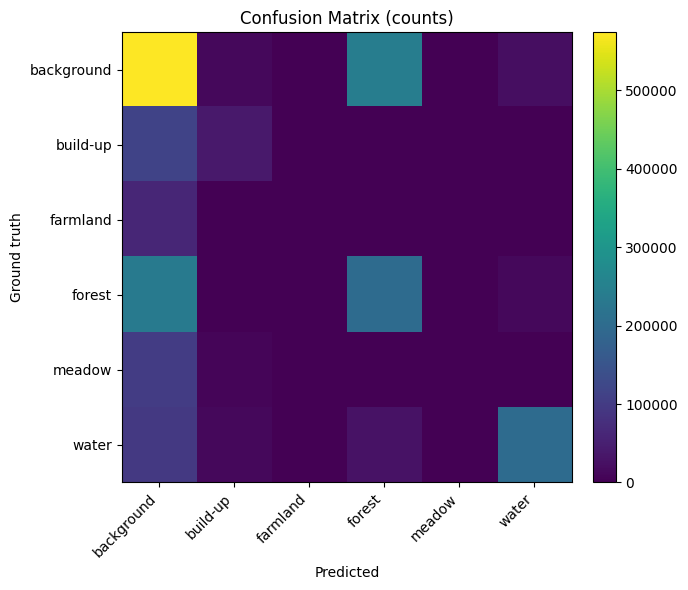

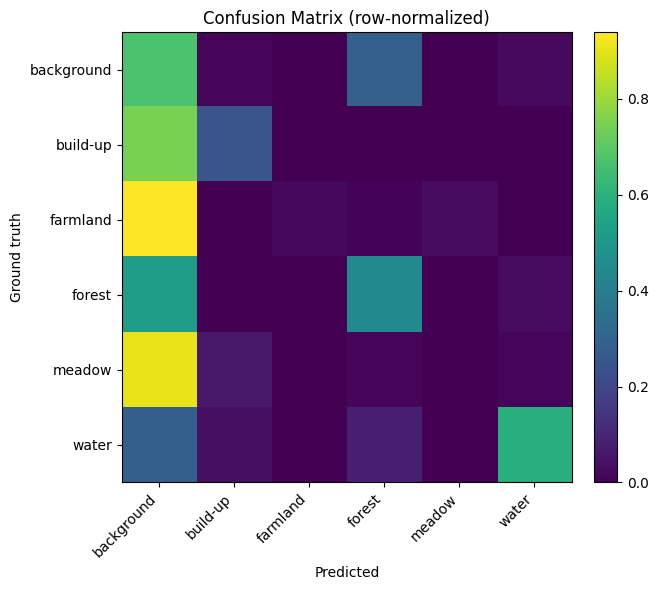

In [ ]:

def plot_confusion_matrix(cm_np: np.ndarray, class_names, normalize=None, annotate=False):
    if normalize == 'true':
        sums = cm_np.sum(axis=1, keepdims=True)
        disp = cm_np / np.clip(sums, 1, None)
        title = "Confusion Matrix (row-normalized)"
    else:
        disp, title = cm_np, "Confusion Matrix (counts)"
    plt.figure(figsize=(7,6))
    im = plt.imshow(disp, cmap='viridis')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted"); plt.ylabel("Ground truth"); plt.title(title)
    if annotate:
        txt = disp if normalize=='true' else cm_np
        for i in range(disp.shape[0]):
            for j in range(disp.shape[1]):
                s = f"{txt[i,j]:.2f}" if normalize=='true' else f"{int(txt[i,j])}"
                plt.text(j, i, s, ha='center', va='center', color='w', fontsize=8)
    plt.tight_layout(); plt.show()

cm_np = cm.cpu().numpy()
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize=None, annotate=False)
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize='true', annotate=False)


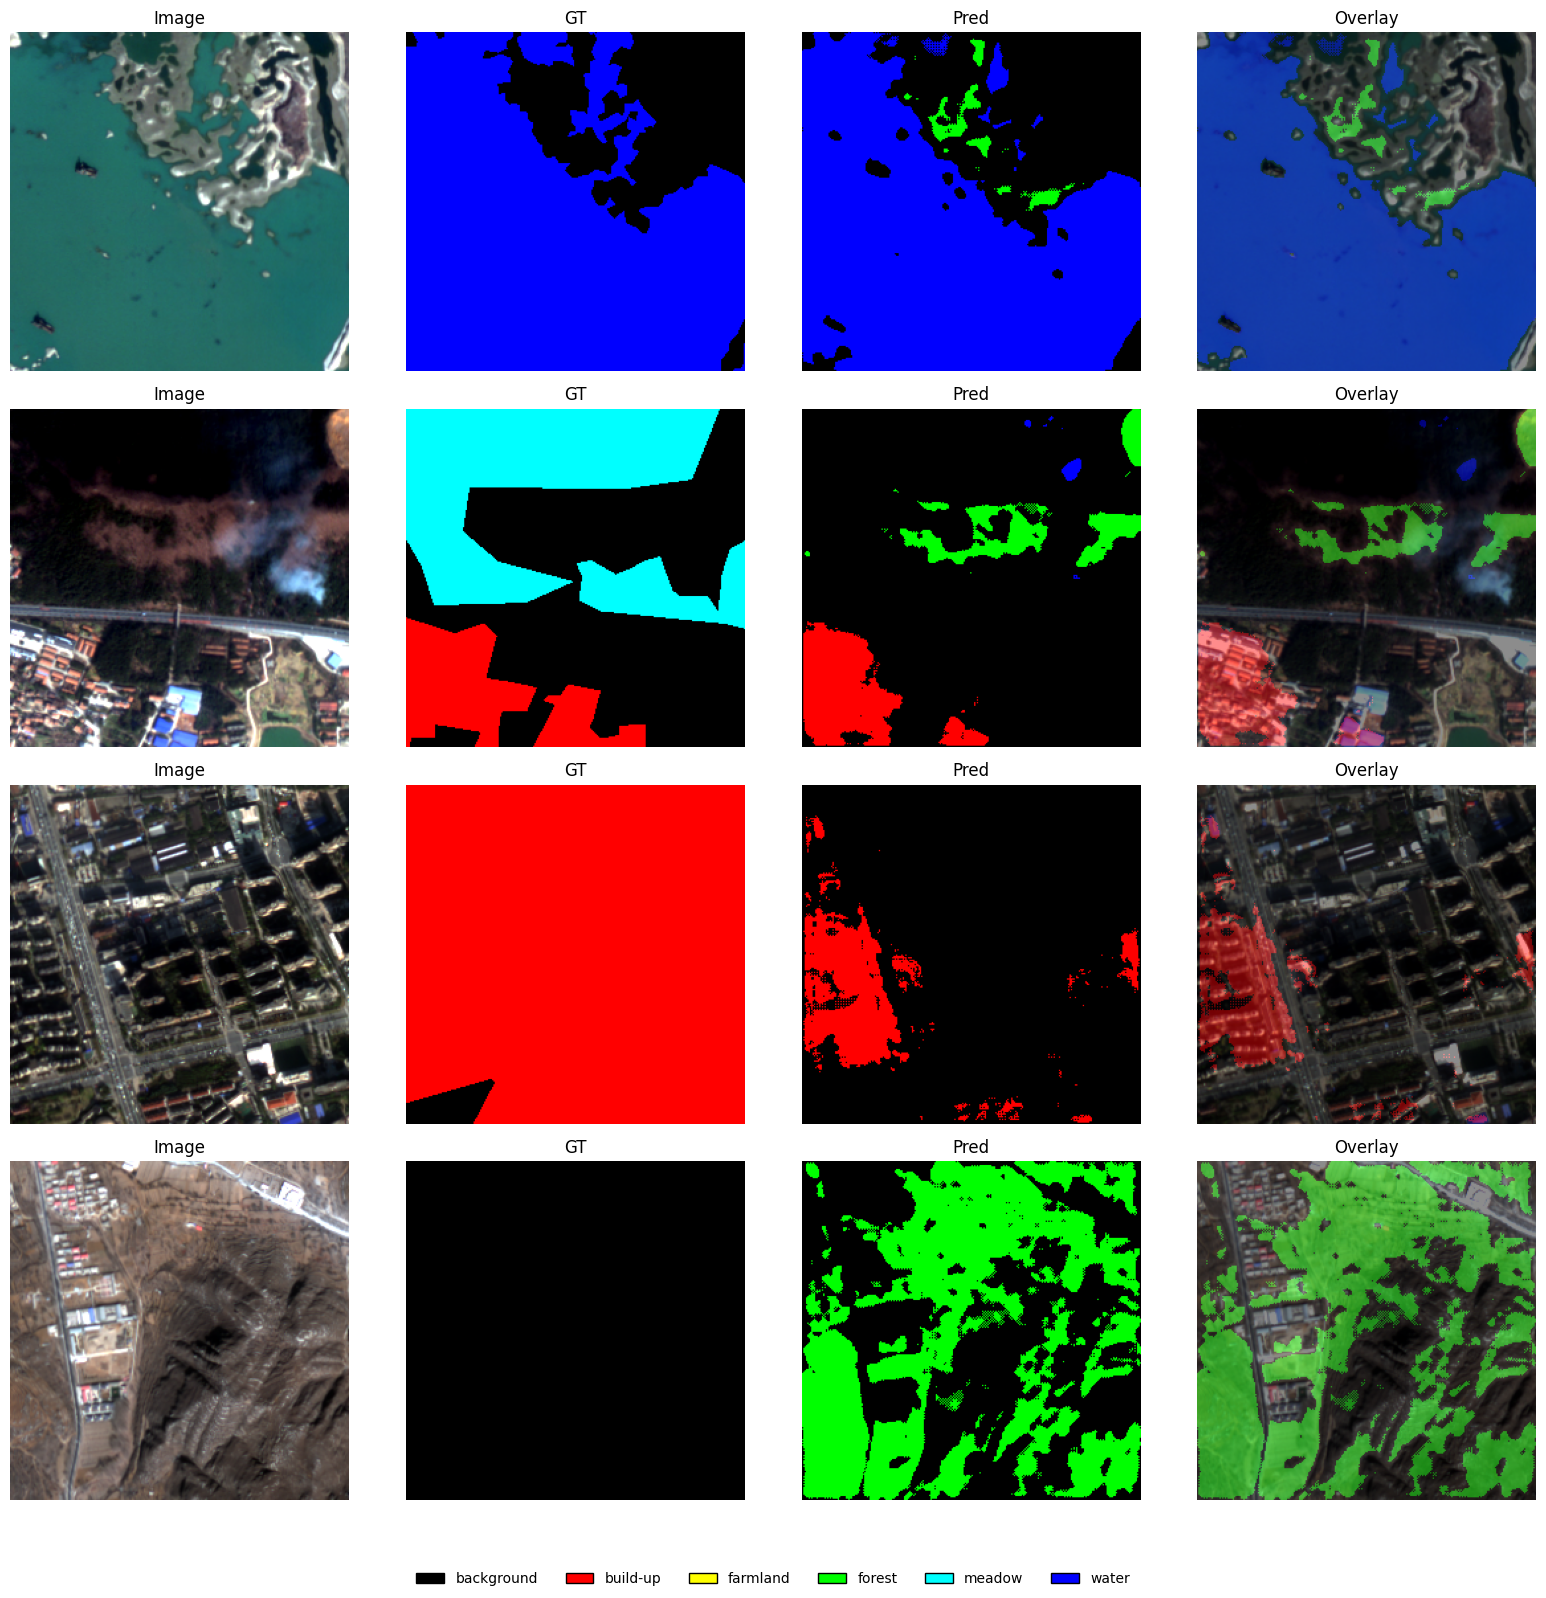

In [ ]:

@torch.no_grad()
def show_val_patches(model, val_loader, device=None, max_items=6, overlay_alpha=0.45):
    device = device or next(model.parameters()).device
    model.eval()
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)
    with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                         enabled=True, dtype=torch.float16):
        logits = model(xb)
    pred = logits.argmax(1).cpu().numpy()
    imgs = (xb.cpu().permute(0,2,3,1).numpy()*255).astype(np.uint8)
    gts  = yb.numpy()
    n = min(len(imgs), max_items)
    fig, axs = plt.subplots(n, 4, figsize=(16, 4*n))
    if n==1: axs = axs[None,:]
    for i in range(n):
        im = imgs[i]; gt=colorize_idx(gts[i]); pr=colorize_idx(pred[i])
        ovl = (im.astype(np.float32)*(1-overlay_alpha)+pr.astype(np.float32)*overlay_alpha).astype(np.uint8)
        axs[i,0].imshow(im);  axs[i,0].set_title("Image"); axs[i,0].axis('off')
        axs[i,1].imshow(gt);  axs[i,1].set_title("GT");    axs[i,1].axis('off')
        axs[i,2].imshow(pr);  axs[i,2].set_title("Pred");  axs[i,2].axis('off')
        axs[i,3].imshow(ovl); axs[i,3].set_title("Overlay");axs[i,3].axis('off')
    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()

show_val_patches(model, val_loader, max_items=4)


In [ ]:

import numpy as np, torch, torch.nn.functional as F
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def rgb_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    out = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for k,(r,g,b) in enumerate(CLASS_COLORS):
        m = (mask_rgb[...,0]==r) & (mask_rgb[...,1]==g) & (mask_rgb[...,2]==b)
        out[m] = k
    return out

def mask_to_class_any(mask_pil: Image.Image) -> np.ndarray:
    if mask_pil.mode in ("I;16","I","L"):        
        return np.array(mask_pil, dtype=np.int64)
    else:                                      
        return rgb_to_class(np.array(mask_pil.convert("RGB"), dtype=np.uint8))

def find_mask_path(img_path: Path, mask_dir: Path, suffix="_label"):
    stem = img_path.stem
    for ext in list(MASK_EXTS) + [img_path.suffix.lower()]:
        p = Path(mask_dir) / f"{stem}{suffix}{ext}"
        if p.exists(): return p
    for p in Path(mask_dir).glob(f"{stem}*label*"):
        if p.suffix.lower() in MASK_EXTS: return p
    raise FileNotFoundError(f"No mask for {img_path.name}")

@torch.no_grad()
def sliding_window_predict_full(model,
                                image_path: Path,
                                patch_size: int = 256,
                                stride: int = 192,
                                device: str = "cuda",
                                accumulate_on: str = "cpu",
                                amp: bool = True,
                                downscale_long_side: int | None = None):
   
    device = device if (device == "cuda" and torch.cuda.is_available()) else "cpu"
    acc_dev = "cpu" if accumulate_on == "cpu" else device

    im = Image.open(image_path).convert("RGB")
    W0, H0 = im.size
    scale = 1.0
    if downscale_long_side and max(W0, H0) > downscale_long_side:
        scale = downscale_long_side / float(max(W0, H0))
        im = im.resize((int(W0*scale), int(H0*scale)), Image.BILINEAR)
    W, H = im.size

    score = torch.zeros((NUM_CLASSES, H, W), dtype=torch.float32, device=acc_dev)
    count = torch.zeros((1,          H, W), dtype=torch.float32, device=acc_dev)

    model.eval().to(device)
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            patch = im.crop((x, y, min(x+patch_size, W), min(y+patch_size, H)))
            t = torch.from_numpy(np.array(patch, np.uint8)).permute(2,0,1).float() / 255.0
            t = t.unsqueeze(0).to(device, non_blocking=True)
            with torch.autocast(device_type=("cuda" if device=="cuda" else "cpu"),
                                 enabled=amp, dtype=torch.float16):
                logits = model(t) 
            
            logits = F.interpolate(logits, size=patch.size[1::-1],
                                   mode="bilinear", align_corners=False).squeeze(0)

            if acc_dev == "cpu":
                score[:, y:y+patch.size[1], x:x+patch.size[0]] += logits.to("cpu")
                count[:, y:y+patch.size[1], x:x+patch.size[0]] += 1
            else:
                score[:, y:y+patch.size[1], x:x+patch.size[0]] += logits
                count[:, y:y+patch.size[1], x:x+patch.size[0]] += 1

    score = score / torch.clamp(count, min=1.0)
    pred = torch.argmax(score, dim=0).to(torch.int64).cpu().numpy()

    
    if scale != 1.0:
        pred = np.array(Image.fromarray(pred.astype(np.uint8))
                        .resize((W0, H0), Image.NEAREST), dtype=np.int64)
    return pred

def show_full_image_triptych(img_path: Path,
                             mask_dir: str,
                             model,
                             patch_size: int = 256,
                             stride: int = 192,
                             downscale_long_side: int | None = 3000,
                             overlay_alpha: float = 0.45,
                             save_to: str | None = None):
    img_path = Path(img_path)
    mask_path = find_mask_path(img_path, Path(mask_dir), suffix="_label")


    img_rgb = np.array(Image.open(img_path).convert("RGB"))
    gt_idx  = mask_to_class_any(Image.open(mask_path))
   
    pred_idx = sliding_window_predict_full(model, img_path,
                                           patch_size=patch_size,
                                           stride=stride,
                                           device="cuda",
                                           accumulate_on="cpu",
                                           amp=True,
                                           downscale_long_side=downscale_long_side)
  
    gt_rgb   = colorize_idx(gt_idx)
    pred_rgb = colorize_idx(pred_idx)
    overlay  = (img_rgb.astype(np.float32)*(1-overlay_alpha)
                + pred_rgb.astype(np.float32)*overlay_alpha).astype(np.uint8)

    fig, axs = plt.subplots(1, 4, figsize=(22, 6))
    axs[0].imshow(img_rgb);  axs[0].set_title("Original");     axs[0].axis("off")
    axs[1].imshow(gt_rgb);   axs[1].set_title("Ground truth"); axs[1].axis("off")
    axs[2].imshow(pred_rgb); axs[2].set_title("Prediction");   axs[2].axis("off")
    axs[3].imshow(overlay);  axs[3].set_title("Overlay");      axs[3].axis("off")

    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1])
    if save_to:
        os.makedirs(Path(save_to).parent, exist_ok=True)
        plt.savefig(save_to, dpi=180, bbox_inches="tight")
        print("Saved:", save_to)
    plt.show()


In [ ]:

iou_list, miou, pa_list, mpa, oa = metrics_from_cm(cm.to('cpu'))
support = cm.sum(dim=1).to(torch.int64).numpy()

df_per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support_px": support,
    "PA": np.array(pa_list, dtype=float),
    "IoU": np.array(iou_list, dtype=float),
})
df_per_class["PA_%"]  = (df_per_class["PA"] * 100).round(2)
df_per_class["IoU_%"] = (df_per_class["IoU"] * 100).round(2)

df_summary = pd.DataFrame({
    "metric": ["mIoU", "mPA", "OA"],
    "value":  [miou,   mpa,   oa]
})
df_summary["value_%"] = (df_summary["value"] * 100).round(2)

from IPython.display import display
display(df_per_class[["class","support_px","PA","IoU","PA_%","IoU_%"]].round(4))
display(df_summary[["metric","value","value_%"]].round(4))


os.makedirs(SAVE_DIR, exist_ok=True)
df_per_class.to_csv(f"{SAVE_DIR}/gid_attnunet_metrics_per_class.csv", index=False)
df_summary.to_csv(f"{SAVE_DIR}/gid_attnunet_metrics_summary.csv", index=False)
print("Saved:")
print(f"  {SAVE_DIR}/gid_attnunet_metrics_per_class.csv")
print(f"  {SAVE_DIR}/gid_attnunet_metrics_summary.csv")


,class,support_px,PA,IoU,PA_%,IoU_%
0,background,851355,0.6741,0.3932,67.41,39.32
1,build-up,155304,0.2484,0.2055,24.84,20.55
2,farmland,65028,0.0191,0.0190,1.91,1.90
3,forest,445814,0.4488,0.2777,44.88,27.77
4,meadow,112099,0.0000,0.0000,0.00,0.00
5,water,336480,0.5940,0.5384,59.40,53.84


,metric,value,value_%
0,mIoU,0.2390,23.90
1,mPA,0.3307,33.07
2,OA,0.5156,51.56


Saved:
  /content/drive/MyDrive/checkpoints_unet_attn/gid_attnunet_metrics_per_class.csv
  /content/drive/MyDrive/checkpoints_unet_attn/gid_attnunet_metrics_summary.csv


In [ ]:


show_val_patches(model, val_loader, max_items=4)

val_imgs = sorted([p for p in Path(VAL_IMG_DIR).iterdir() if p.suffix.lower() in IMG_EXTS])
print(f"Found {len(val_imgs)} val files");
show_full_image_triptych(val_imgs[0], VAL_MASK_DIR, model, patch_size=256, stride=192, downscale_long_side=3000)


Output hidden; open in https://colab.research.google.com to view.